# Network Chart

This section showcases the network chart. It contains examples of how to create network charts using the [datachart.charts.NetworkChart](../../../references/charts/#datachart.charts.NetworkChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-network-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the network charts are created using the `NetworkChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import NetworkChart

## Network Chart Input Attributes

The `NetworkChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the nodes and the edges between them. A network is a `{"nodes": [...], "edges": [...]}` dict; `nodes` may be omitted, in which case the nodes are read from the edges. A list of such dicts draws one network per subplot.

```python
NetworkChart(
    data={                                              # The network (or a list of such dicts, one network per subplot)
        "nodes": [                                      # Optional; inferred from the edges in first-seen order when omitted
            {
                "id": str,                              # The node identifier the edges refer to; unique within a chart
                "label": Optional[str],                 # The drawn label; the id by default, "" draws nothing
                "size": Optional[Union[int, float]],    # Mapped by square root to the marker area; must be greater than 0
                "group": Optional[str],                 # The group the node is colored by
                "emphasis": Optional[str],              # "background" mutes the node and its edges, "highlight" strokes its border
                "x": Optional[float],                   # The position in the 0-1 layout space; NETWORK_LAYOUT.FIXED only
                "y": Optional[float],
            },
            ...
        ],
        "edges": [
            {
                "source": str,                          # The id of the node the edge leaves
                "target": str,                          # The id of the node the edge enters
                "weight": Optional[Union[int, float]],  # Mapped to the edge width; must be greater than 0
            },
            ...
        ],
    },
    layout=Optional[str],                               # How the nodes are placed, a NETWORK_LAYOUT constant (SPRING by default)
    directed=Optional[bool],                            # Whether the edges end in an arrowhead (False by default)
    seed=Optional[int],                                 # The seed of the spring layout (0 by default)
    show_values=Optional[bool],                         # Whether to write each edge's weight at its midpoint
    value_format=Optional[str],                         # The format of the values, a VALUE_FORMAT constant or a format string
    show_legend=Optional[bool],                         # Whether to list the node groups in a legend
    style={                                             # The style of the chart (optional; a list for multiple charts)
        "plot_network_node_color":            Optional[str],    # The node color; overrides the palette
        "plot_network_node_alpha":            Optional[float],  # The node alpha (0.95 by default)
        "plot_network_node_marker":           Optional[str],    # The node marker shape ("o" by default)
        "plot_network_node_size":             Optional[float],  # The marker area of a node without size (200 by default)
        "plot_network_node_size_min":         Optional[float],  # The marker area of the smallest sized node (80 by default)
        "plot_network_node_size_max":         Optional[float],  # The marker area of the largest sized node (900 by default)
        "plot_network_node_edge_color":       Optional[str],    # The node stroke color (white by default)
        "plot_network_node_edge_width":       Optional[float],  # The node stroke width (0.8 by default)
        "plot_network_edge_style":            Optional[str],    # The edge geometry: ARROW_STYLE.CURVE (default) or ARROW_STYLE.STRAIGHT
        "plot_network_edge_curve":            Optional[float],  # The bow of a curved edge; the sign picks the side (0.2 by default)
        "plot_network_edge_color":            Optional[str],    # The edge color (grey by default)
        "plot_network_edge_alpha":            Optional[float],  # The edge alpha (0.6 by default)
        "plot_network_edge_width_min":        Optional[float],  # The width of the lightest edge, and of an edge without weight (0.8 by default)
        "plot_network_edge_width_max":        Optional[float],  # The width of the heaviest edge (4 by default)
        "plot_network_highlight_edge_width":  Optional[float],  # The stroke width of a highlighted node (2 by default)
        "plot_network_label_halo_width":      Optional[float],  # The white halo behind the labels; 0 disables it (2 by default)
    },
    subtitle=Optional[str],                             # The chart subtitle (or list for multiple charts)
    title=Optional[str],                                # The chart title
    figsize=Optional[Tuple[float, float]],              # The figure size
    subplots=Optional[bool],                            # Whether to draw each chart in its own subplot
    max_cols=Optional[int],                             # The maximum number of subplot columns
    texts=Optional[Union[dict, List[dict]]],            # The text annotations
)
```

For more details, see the [datachart.charts.NetworkChart](../../../references/charts/#datachart.charts.NetworkChart) function.

## Basics

The examples in this guide share one dataset: the modules of a small web service and the imports between them. Each module has a size in lines of code and belongs to a layer of the architecture; each import is an edge from the importing module to the imported one, weighted by how many names it pulls in. The numbers live in the cell below. A dependency graph is the textbook network: the question is what depends on what, and a node-link diagram shows every module and every import at once.

In [2]:
# The modules of a small web service: (layer, lines of code)
MODULES = {
    "app": ("interface", 620),
    "cli": ("interface", 340),
    "api": ("service", 910),
    "auth": ("service", 480),
    "jobs": ("service", 260),
    "models": ("core", 1150),
    "storage": ("core", 730),
    "config": ("core", 190),
    "utils": ("core", 410),
}

# The imports between them: (importing module, imported module, names imported)
IMPORTS = [
    ("app", "api", 12),
    ("app", "auth", 4),
    ("app", "config", 2),
    ("cli", "api", 6),
    ("cli", "jobs", 3),
    ("cli", "config", 2),
    ("api", "models", 15),
    ("api", "auth", 5),
    ("api", "storage", 7),
    ("auth", "models", 6),
    ("auth", "utils", 3),
    ("jobs", "storage", 4),
    ("jobs", "models", 5),
    ("models", "utils", 8),
    ("storage", "config", 3),
    ("storage", "utils", 4),
]

service = {
    "nodes": [
        {"id": module, "group": layer, "size": lines}
        for module, (layer, lines) in MODULES.items()
    ],
    "edges": [
        {"source": importer, "target": imported, "weight": names}
        for importer, imported, names in IMPORTS
    ],
}

The data is one dict with a `nodes` list and an `edges` list. Every node is a dict with an `id` that is unique within the chart; every edge is a dict whose `source` and `target` name two different nodes by id. Everything else is optional: a node's `label` (the id by default), its `size` and `group`, an edge's `weight`. The `nodes` list itself is optional too — without it, the nodes are read from the edges in the order they are first mentioned. A repeated id, an edge naming an unknown node or joining a node to itself, and a zero or negative `size` or `weight` raise a `ValueError`.

In [3]:
service["nodes"][:2], service["edges"][:2]

([{'id': 'app', 'group': 'interface', 'size': 620},
  {'id': 'cli', 'group': 'interface', 'size': 340}],
 [{'source': 'app', 'target': 'api', 'weight': 12},
  {'source': 'app', 'target': 'auth', 'weight': 4}])

**Basic example.** Only the `data` argument is required to draw the network chart. The nodes are placed by a force-directed layout — linked modules pull together, every pair pushes apart — and joined by curved edges. With no `group` every node takes one color, and the sizes and weights below are mapped to marker area and edge width straight away; the sections that follow show each encoding on its own.

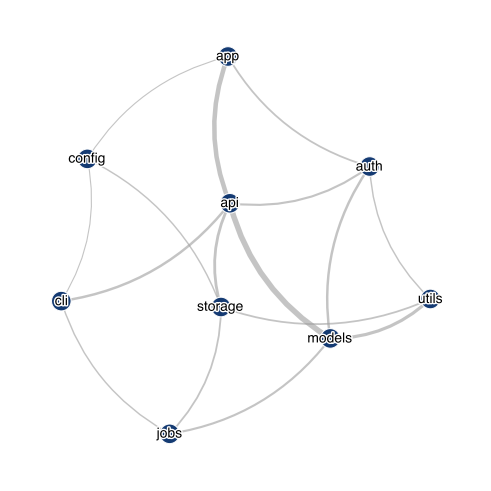

In [4]:
NetworkChart(
    # add the data to the chart
    data={"edges": service["edges"]}
).show()

## Customizing the Network Chart

Every customization is either a keyword argument of `NetworkChart` or a `plot_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title and figure size](#title-and-figure-size) |
| place the nodes another way                 | `layout`, `seed`                                                        | [Layouts](#layouts) |
| put every node where I say                  | `layout=NETWORK_LAYOUT.FIXED` and `"x"`, `"y"` on the nodes             | [Layouts](#layouts) |
| show the direction of the edges             | `directed`                                                              | [Directed edges](#directed-edges) |
| size the edges and the nodes by a value     | `"weight"` on the edges, `"size"` on the nodes                          | [Edge weights and node sizes](#edge-weights-and-node-sizes) |
| color the nodes by a category               | `"group"` on the nodes, `show_legend`                                   | [Groups and the legend](#groups-and-the-legend) |
| mute or outline a node                      | `"emphasis"` on the node                                                | [Emphasis](#emphasis) |
| write the weights on the edges              | `show_values`, `value_format`                                           | [Edge values](#edge-values) |
| draw straight edges, or bow them more       | `style={"plot_network_edge_style": ..., "plot_network_edge_curve": ...}` | [Node and edge style](#node-and-edge-style) |
| change the node markers or the edge color   | `style={"plot_network_node_marker": ..., "plot_network_edge_color": ...}` | [Node and edge style](#node-and-edge-style) |
| drop the halo behind the labels             | `style={"plot_network_label_halo_width": 0}`                            | [Node and edge style](#node-and-edge-style) |
| annotate a point of the chart               | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several networks side by side          | `subplots`                                                              | [Subplots](#subplots) |
| arrange a network next to other charts      | `Grid`                                                                  | [Composing network charts](#composing-network-charts) |

### Title and figure size

To add the chart title, add the `title` attribute. A network chart has no axes, so there are no axis labels to set. To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. The layout always keeps a square aspect, so a wide figure leaves room beside the drawing rather than stretching it.

In [5]:
from datachart.constants import FIG_SIZE

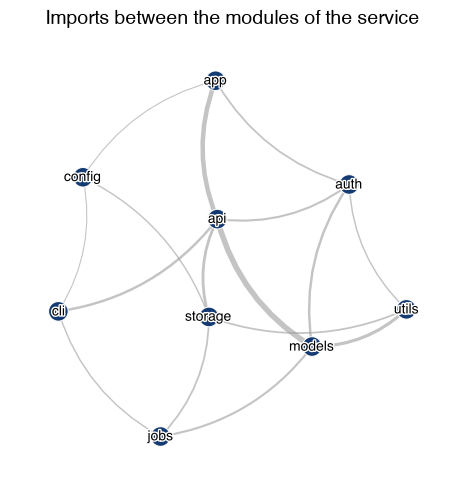

In [6]:
NetworkChart(
    data={"edges": service["edges"]},
    # add the title
    title="Imports between the modules of the service",
    # add to determine the figure size
    figsize=FIG_SIZE.SQUARE,
).show()

### Layouts

The `layout` attribute says how the nodes are placed, using the [datachart.constants.NETWORK_LAYOUT](../../../references/constants/#datachart.constants.NETWORK_LAYOUT) constants. The default, `SPRING`, is a force-directed layout: it is seeded by the `seed` attribute (`0` by default), so the same data draws the same picture every time, and another seed gives another arrangement of the same graph. `CIRCULAR` spaces the nodes evenly on a circle in input order, starting at the top — a good choice when the nodes have a natural order or the layout must be predictable. `FIXED` places every node at its own `x` and `y`, given on the node in the `0`–`1` layout space; a node without them raises a `ValueError`. An edge's weight never moves a node: it is a visual cue only.

In [7]:
from datachart.constants import NETWORK_LAYOUT

`layout` and `seed` apply to every network in a figure, so the comparison below draws three figures and arranges them with [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) (see [Composing network charts](#composing-network-charts)). The two spring layouts only differ in the seed; the circular one has nothing random.

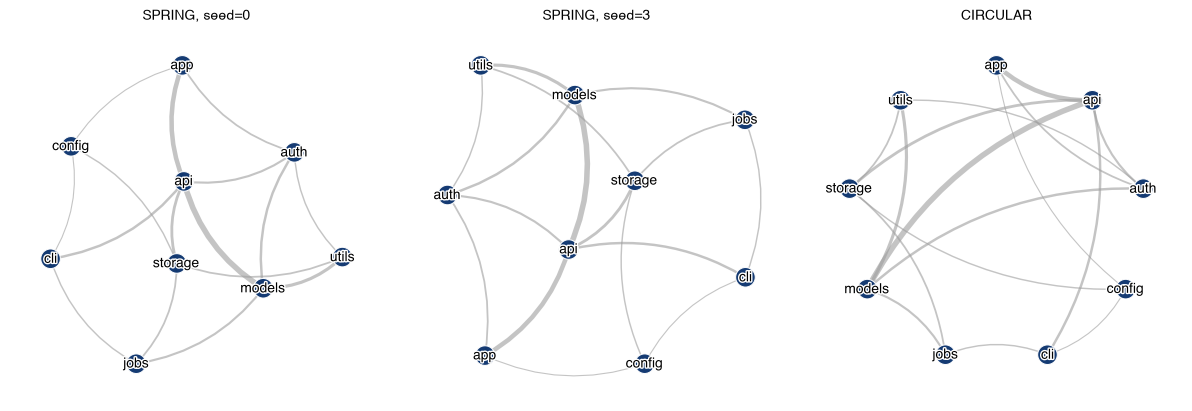

In [8]:
from datachart.utils import Grid

imports = {"edges": service["edges"]}
Grid(
    [[
        NetworkChart(imports, title="SPRING, seed=0"),
        # another arrangement of the same graph
        NetworkChart(imports, seed=3, title="SPRING, seed=3"),
        # the nodes on a circle in input order
        NetworkChart(imports, layout=NETWORK_LAYOUT.CIRCULAR, title="CIRCULAR"),
    ]],
    figsize=(12, 4),
).show()

To place the nodes by hand, give each an `x` and a `y` and pick the fixed layout — here the layers of the architecture become rows, top to bottom:

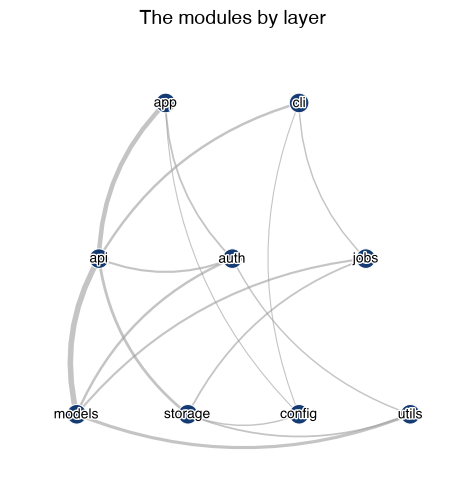

In [9]:
ROW = {"interface": 0.85, "service": 0.5, "core": 0.15}
COLUMN = {
    "app": 0.35, "cli": 0.65,
    "api": 0.2, "auth": 0.5, "jobs": 0.8,
    "models": 0.15, "storage": 0.4, "config": 0.65, "utils": 0.9,
}

layered = {
    "nodes": [
        {"id": module, "x": COLUMN[module], "y": ROW[layer]}
        for module, (layer, _) in MODULES.items()
    ],
    "edges": service["edges"],
}

NetworkChart(
    data=layered,
    # every node at its own x and y
    layout=NETWORK_LAYOUT.FIXED,
    title="The modules by layer",
    figsize=FIG_SIZE.SQUARE,
).show()

### Directed edges

To show which way an edge goes, add the `directed` attribute. Each edge then ends in an arrowhead at its target, stopping at the node's edge, and an edge and its reverse draw as two separate arrows, each bowing to its own side. Without `directed` (the default), a network is undirected: an edge and its reverse draw as one line. The imports have a direction — the importing module points at the one it imports — so the dependency graph reads best directed.

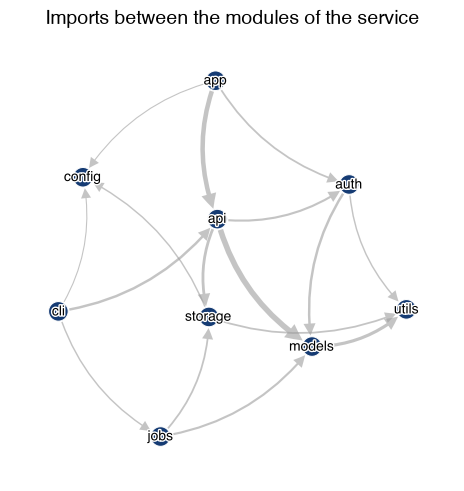

In [10]:
NetworkChart(
    data={"edges": service["edges"]},
    # arrowheads from the importing module to the imported one
    directed=True,
    title="Imports between the modules of the service",
    figsize=FIG_SIZE.SQUARE,
).show()

### Edge weights and node sizes

An edge's `weight` sets its width, linearly between `plot_network_edge_width_min` and `plot_network_edge_width_max` over the weights in the chart; an edge without a weight draws at the minimum. A node's `size` sets its marker area, by square root between `plot_network_node_size_min` and `plot_network_node_size_max`, so a node four times the size draws twice the marker; a node without a size draws at `plot_network_node_size`. The example carries both: the width of an import is how many names it pulls in, and a module's marker grows with its lines of code.

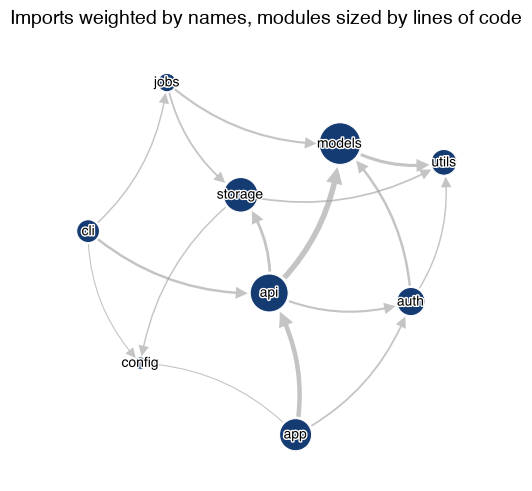

In [11]:
NetworkChart(
    # the edges carry a weight, the nodes a size
    data={"nodes": [{"id": m, "size": lines} for m, (_, lines) in MODULES.items()], "edges": service["edges"]},
    directed=True,
    title="Imports weighted by names, modules sized by lines of code",
    figsize=FIG_SIZE.SQUARE,
).show()

### Groups and the legend

A node's `group` colors it: the groups take the palette colors in the order they are first seen, and nodes without a group share the first color. To name the groups, add the `show_legend` attribute; the legend sits beside the drawing, since the nodes fill the axes. The example colors every module by its layer of the architecture.

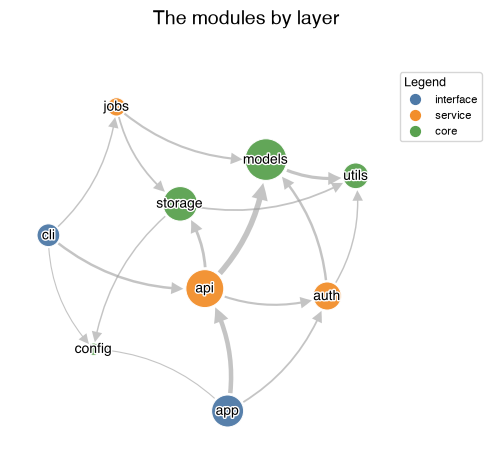

In [12]:
NetworkChart(
    # the nodes carry a group
    data=service,
    directed=True,
    # name the layers beside the chart
    show_legend=True,
    title="The modules by layer",
    figsize=FIG_SIZE.SQUARE,
).show()

### Emphasis

Emphasis is set per node with the `emphasis` key, using the [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) roles. `background` mutes a node, its label, and every edge touching it into the theme's muted color; `highlight` strokes the node's border in the text color. Roles are explicit: highlighting one node does not mute the others, and the `emphasis` argument of the function itself is not supported — pass the roles on the nodes. The example highlights the module every other module ends up depending on, and mutes the command-line entry point and what only it uses.

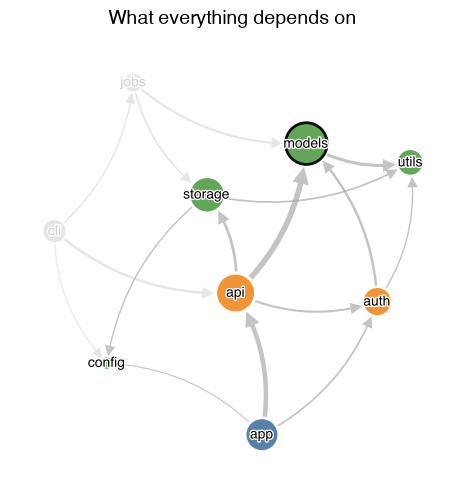

In [13]:
from datachart.constants import EMPHASIS

ROLES = {"models": EMPHASIS.HIGHLIGHT, "cli": EMPHASIS.BACKGROUND, "jobs": EMPHASIS.BACKGROUND}

NetworkChart(
    data={
        "nodes": [
            {"id": module, "group": layer, "size": lines, **({"emphasis": ROLES[module]} if module in ROLES else {})}
            for module, (layer, lines) in MODULES.items()
        ],
        "edges": service["edges"],
    },
    directed=True,
    title="What everything depends on",
    figsize=FIG_SIZE.SQUARE,
).show()

### Edge values

To write each edge's weight at its midpoint, add the `show_values` attribute. The `value_format` attribute formats the values: use one of the [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constants or any `"{x:.1f}"`, `"{:.1f}%"`, or `"%g"` style string. A value sits on the drawn edge — on the bow of a curved one — behind the same halo as the labels; an edge without a weight gets no value.

In [14]:
from datachart.constants import VALUE_FORMAT

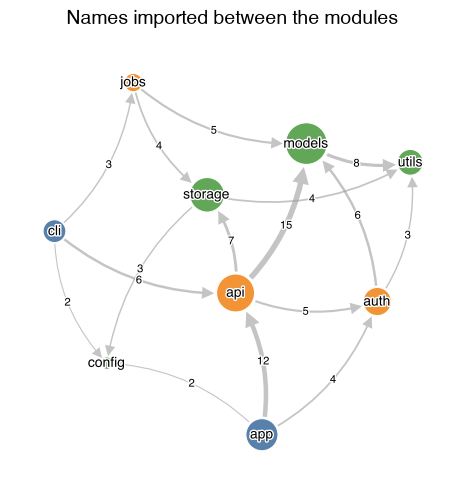

In [15]:
NetworkChart(
    data=service,
    directed=True,
    # write the number of imported names on the edges
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="Names imported between the modules",
    figsize=FIG_SIZE.SQUARE,
).show()

### Node and edge style

To change the node and edge style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.NetworkStyleAttrs](../../../references/typings/#datachart.typings.NetworkStyleAttrs) typing. The nodes are a scatter and take the `plot_network_node_*` keys: the marker, its alpha and stroke, and the three areas the sizes map onto; `plot_network_node_color` overrides the palette for every node. The edges take `plot_network_edge_color` and `plot_network_edge_alpha`, and the width range the weights map onto.

The edge geometry is `plot_network_edge_style`, one of the [datachart.constants.ARROW_STYLE](../../../references/constants/#datachart.constants.ARROW_STYLE) looks: `CURVE` (the default) bows every edge by `plot_network_edge_curve`, whose sign picks the side, and `STRAIGHT` draws straight lines. The headed looks are rejected — the arrowhead of a network edge comes from the `directed` attribute, not from the style. The example draws the graph with straight, darker edges and square markers.

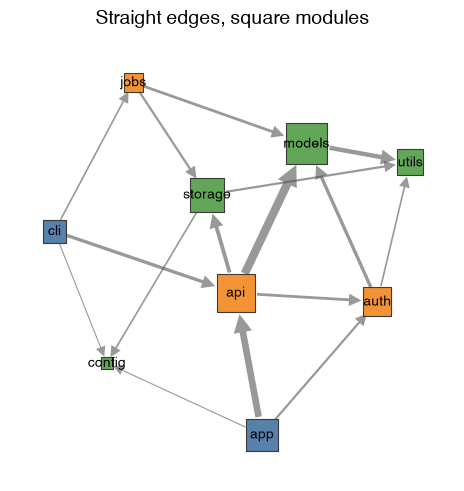

In [16]:
from datachart.constants import ARROW_STYLE, LINE_MARKER

NetworkChart(
    data=service,
    directed=True,
    style={
        # straight edges
        "plot_network_edge_style": ARROW_STYLE.STRAIGHT,
        # darker and heavier
        "plot_network_edge_color": "#555555",
        "plot_network_edge_width_max": 6,
        # square markers with a dark stroke
        "plot_network_node_marker": LINE_MARKER.SQUARE,
        "plot_network_node_edge_color": "#333333",
        # no halo behind the labels
        "plot_network_label_halo_width": 0,
    },
    title="Straight edges, square modules",
    figsize=FIG_SIZE.SQUARE,
).show()

A larger `plot_network_edge_curve` bows the edges more, which helps a dense graph keep its edges apart; a negative one bows them the other way:

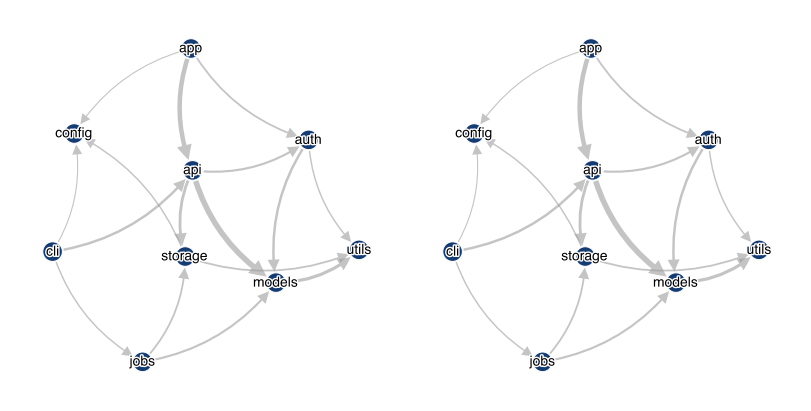

In [17]:
NetworkChart(
    data=[
        {"edges": service["edges"], "subtitle": "edge_curve=0.5", "style": {"plot_network_edge_curve": 0.5}},
        {"edges": service["edges"], "subtitle": "edge_curve=-0.2", "style": {"plot_network_edge_curve": -0.2}},
    ],
    directed=True,
    max_cols=2,
    figsize=(8, 4),
).show()

### Text annotations

To place text on the chart, add the `texts` attribute with the [datachart.typings.TextAttrs](../../../references/typings/#datachart.typings.TextAttrs) records. The layout spans `0`–`1` in both directions, so `x` and `y` are fractions of the drawing; the [Text Annotations](../utility/annotations.ipynb) guide covers the connector and box options. The example notes what the fixed, layered layout shows.

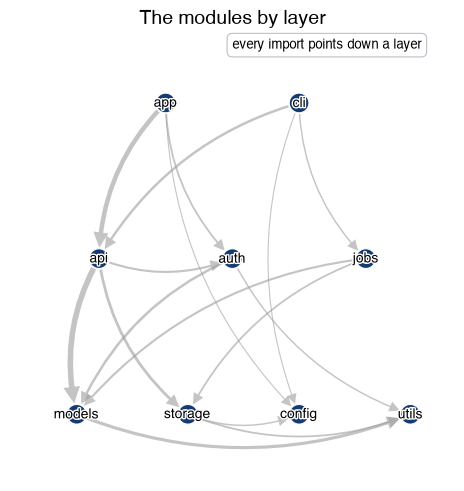

In [18]:
NetworkChart(
    data=layered,
    layout=NETWORK_LAYOUT.FIXED,
    directed=True,
    texts={
        "x": 0.5,
        "y": 0.98,
        "text": "every import points down a layer",
        "ha": "center",
        "va": "top",
    },
    title="The modules by layer",
    figsize=FIG_SIZE.SQUARE,
).show()

## Multiple Network Charts

### Subplots

A list of networks draws each in its own subplot; there is no overlay of two networks on one axes, so `subplots` is implied. The `subtitle` becomes the subplot title and the `title` is positioned to be global for all charts. The `max_cols` attribute limits the number of columns. The example draws the imports of the service layer and of the core layer as two separate graphs.

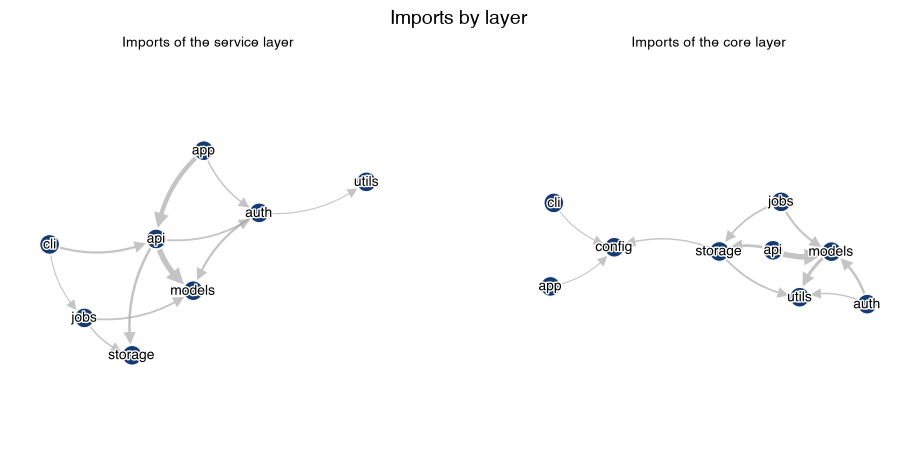

In [19]:
def layer_imports(layer):
    modules = {m for m, (l, _) in MODULES.items() if l == layer}
    return {
        "edges": [
            {"source": s, "target": t, "weight": w}
            for s, t, w in IMPORTS
            if s in modules or t in modules
        ]
    }

NetworkChart(
    # one network per layer
    data=[layer_imports("service"), layer_imports("core")],
    subtitle=["Imports of the service layer", "Imports of the core layer"],
    directed=True,
    max_cols=2,
    title="Imports by layer",
    figsize=(10, 4.5),
).show()

### Composing Network Charts

A network chart owns its axes: there is no shared coordinate space to overlay other charts on, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a network figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it next to other figures as an ordinary cell, keeping the layout it was drawn with. The grid pairs the dependency graph with a [datachart.charts.BarChart](../../../references/charts/#datachart.charts.BarChart) of the module sizes.

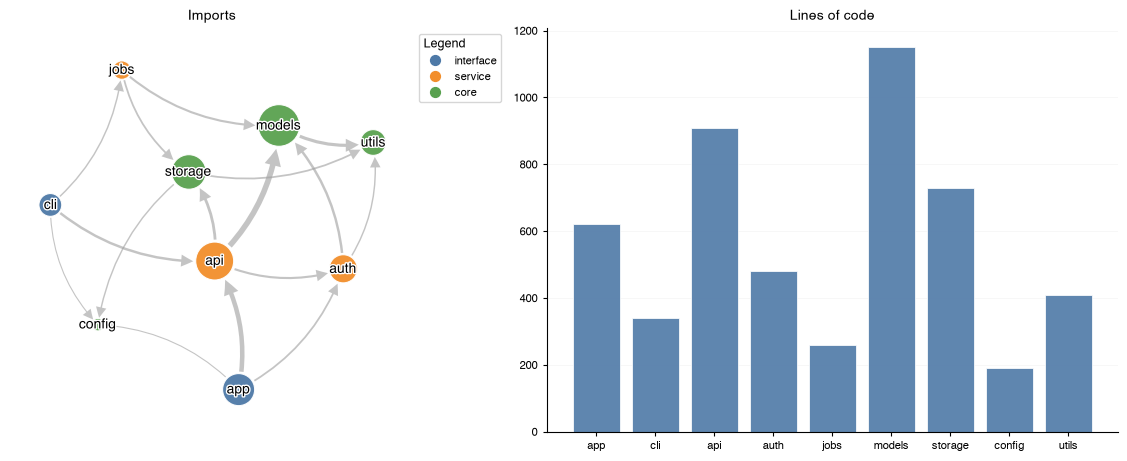

In [20]:
from datachart.charts import BarChart
from datachart.utils import Grid

graph = NetworkChart(data=service, directed=True, show_legend=True, title="Imports")
sizes = BarChart(
    data=[{"label": m, "y": lines} for m, (_, lines) in MODULES.items()],
    title="Lines of code",
)
Grid([[graph, sizes]], figsize=(12, 4.5)).show()

### Themes

A theme sets the palette, the node strokes and the fonts of every chart at once; see the [Theme Gallery](../../styling/theme-gallery.ipynb) for the whole suite under each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [datachart.constants.THEME](../../../references/constants/#datachart.constants.THEME) constant, and reset the configuration afterwards so the following charts draw in the default again.

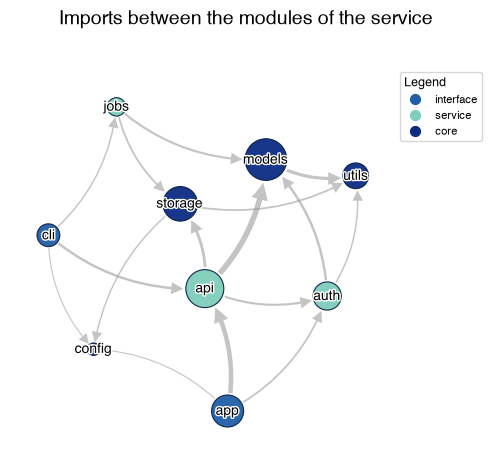

In [21]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = NetworkChart(
    data=service,
    directed=True,
    show_legend=True,
    title="Imports between the modules of the service",
    figsize=FIG_SIZE.SQUARE,
)
config.reset_config()
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [22]:
from datachart.utils import save_figure

figure = NetworkChart(
    data=service,
    directed=True,
    title="Imports between the modules of the service",
)
save_figure(figure, "./fig_networkchart.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work. Each one states what it shows; any derived quantity is computed in the code, and the data is illustrative.

### Example 1: Who Reviews Whose Code (Undirected, Groups, Sizes, and a Highlight)

A team's code review pairs over a quarter: an edge joins two people who reviewed each other's pull requests, weighted by how many reviews they exchanged, and a person's node grows with the reviews they gave. Reviews flow both ways, so the network is undirected; the teams are the groups, and the one person reviewing across every team is highlighted.

In [23]:
REVIEWERS = {
    "Ana": ("Backend", 41), "Bo": ("Backend", 18), "Cy": ("Backend", 12),
    "Di": ("Frontend", 33), "Ed": ("Frontend", 15), "Flo": ("Frontend", 9),
    "Gus": ("Data", 27), "Hal": ("Data", 11),
}
REVIEW_PAIRS = [
    ("Ana", "Bo", 14), ("Ana", "Cy", 6), ("Bo", "Cy", 5),
    ("Di", "Ed", 11), ("Di", "Flo", 7), ("Ed", "Flo", 3),
    ("Gus", "Hal", 9),
    ("Ana", "Di", 8), ("Ana", "Gus", 6), ("Ana", "Ed", 2), ("Di", "Gus", 3), ("Bo", "Hal", 1),
]

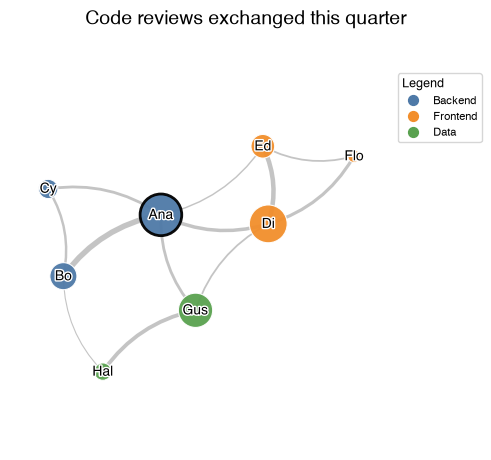

In [24]:
reviews = {
    "nodes": [
        {
            "id": person,
            "group": team,
            "size": given,
            # the reviewer every team leans on
            **({"emphasis": EMPHASIS.HIGHLIGHT} if person == "Ana" else {}),
        }
        for person, (team, given) in REVIEWERS.items()
    ],
    "edges": [{"source": a, "target": b, "weight": n} for a, b, n in REVIEW_PAIRS],
}

NetworkChart(
    data=reviews,
    show_legend=True,
    title="Code reviews exchanged this quarter",
    figsize=FIG_SIZE.SQUARE,
).show()

### Example 2: Container Traffic Between Ports (Directed, Values, and a Fixed Layout)

Container shipments between six ports in a month, in thousands of units. A shipment goes one way, so the network is directed, and a port pair trading both ways shows as two arrows; the values are written on the edges. The ports keep their rough geographic positions through the fixed layout, and the two ports on the busiest lane are highlighted.

In [25]:
PORTS = {
    "Shanghai": (0.85, 0.7), "Singapore": (0.75, 0.25), "Dubai": (0.5, 0.45),
    "Rotterdam": (0.2, 0.8), "Los Angeles": (0.1, 0.3), "Santos": (0.35, 0.1),
}
SHIPMENTS = [
    ("Shanghai", "Rotterdam", 96), ("Rotterdam", "Shanghai", 41),
    ("Shanghai", "Los Angeles", 88), ("Los Angeles", "Shanghai", 37),
    ("Shanghai", "Singapore", 52), ("Singapore", "Dubai", 30), ("Dubai", "Rotterdam", 27),
    ("Singapore", "Rotterdam", 44), ("Santos", "Rotterdam", 18), ("Santos", "Shanghai", 22),
    ("Rotterdam", "Santos", 9), ("Los Angeles", "Santos", 7),
]

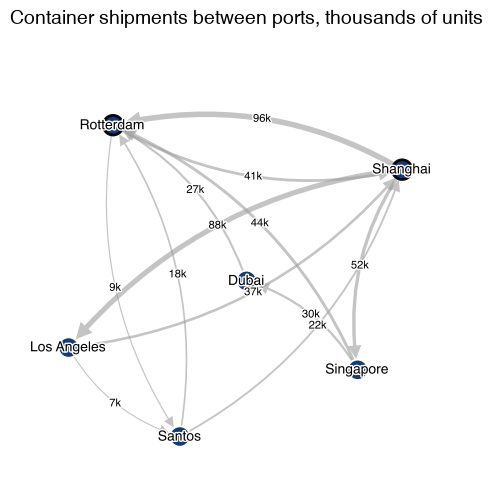

In [26]:
busiest = max(SHIPMENTS, key=lambda s: s[2])

traffic = {
    "nodes": [
        {
            "id": port,
            "x": x,
            "y": y,
            # the two ends of the busiest lane
            **({"emphasis": EMPHASIS.HIGHLIGHT} if port in busiest[:2] else {}),
        }
        for port, (x, y) in PORTS.items()
    ],
    "edges": [{"source": s, "target": t, "weight": k} for s, t, k in SHIPMENTS],
}

NetworkChart(
    data=traffic,
    layout=NETWORK_LAYOUT.FIXED,
    directed=True,
    show_values=True,
    value_format="{x:.0f}k",
    title="Container shipments between ports, thousands of units",
    figsize=FIG_SIZE.SQUARE,
).show()